
FIRST 5 ROWS
   _id                 time    val
0    1  2016-08-18T10:55:00  50.00
1    2  2016-08-18T11:00:00  50.12
2    3  2016-08-18T11:05:00  50.00
3    4  2016-08-18T11:10:00  50.00
4    5  2016-08-18T11:15:00  51.92

DATASET INFO
<class 'pandas.DataFrame'>
DatetimeIndex: 26387 entries, 2016-08-18 10:55:00 to 2017-12-18 08:25:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   _id     26387 non-null  int64  
 1   val     26387 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 618.4 KB
None

MONOTONICITY CHECK
Is Sequentially Ordered?: True

FREQUENCY INSPECTION
Frequency Variation StdDev: 30470.90223263589

MISSING VALUE CHECK
val    0.0
dtype: float64

RESAMPLED DATA
                       val
time                      
2016-08-18 10:45:00  50.00
2016-08-18 11:00:00  50.04
2016-08-18 11:15:00  51.41
2016-08-18 11:30:00  50.27
2016-08-18 11:45:00  50.00

INTERPOLATED DATA
                       val
time    

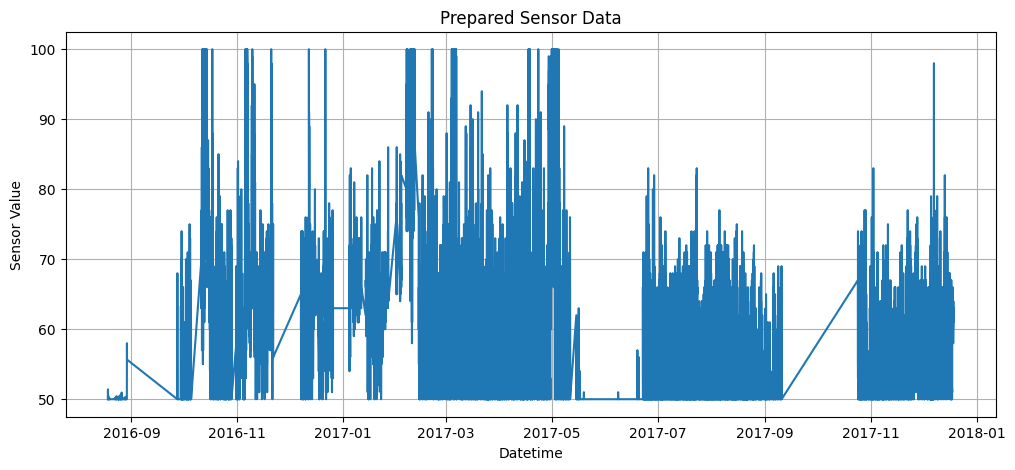


PARQUET FILE SAVED SUCCESSFULLY

PRACTICAL COMPLETED SUCCESSFULLY


In [7]:
# ==========================================
# PR_24
# Structured Ingestion & Preparation
# Sensor Data Dataset
# ==========================================

# ---------- IMPORT LIBRARIES ----------

import pandas as pd
import matplotlib.pyplot as plt

# ---------- STEP 1: LOAD DATASET ----------

df = pd.read_csv("sensor_data.csv")

print("\nFIRST 5 ROWS")
print(df.head())

# ---------- STEP 2: CONVERT DATETIME ----------

df['time'] = pd.to_datetime(
    df['time'],
    errors='coerce'
)

# Remove invalid datetime rows
df = df.dropna(subset=['time'])

# ---------- STEP 3: SET DATETIME INDEX ----------

df = df.set_index('time')

# Sort sequentially
df = df.sort_index()

print("\nDATASET INFO")
print(df.info())

# ---------- STEP 4: KEEP REQUIRED COLUMN ----------

# Convert sensor value column to numeric
df['val'] = pd.to_numeric(
    df['val'],
    errors='coerce'
)

# Remove invalid rows
df = df.dropna(subset=['val'])

# Keep only required column
df = df[['val']]

# ---------- STEP 5: VALIDATION PROTOCOL ----------

# STEP 5.1: MONOTONICITY CHECK

print("\nMONOTONICITY CHECK")

is_monotonic = df.index.is_monotonic_increasing

print("Is Sequentially Ordered?:", is_monotonic)

# STEP 5.2: FREQUENCY INSPECTION

print("\nFREQUENCY INSPECTION")

time_deltas = (
    df.index.to_series()
    .diff()
    .dt.total_seconds()
)

freq_std = time_deltas.std()

print("Frequency Variation StdDev:", freq_std)

# STEP 5.3: MISSING VALUE CHECK

print("\nMISSING VALUE CHECK")

missing_ratio = df.isnull().mean() * 100

print(missing_ratio)

# ---------- STEP 6: RESAMPLING ----------

# Convert to regular 15-minute intervals

df_resampled = (
    df
    .resample('15min')
    .mean()
)

print("\nRESAMPLED DATA")
print(df_resampled.head())

# ---------- STEP 7: INTERPOLATION ----------

# Fill gaps using time interpolation

df_resampled['val'] = (
    df_resampled['val']
    .interpolate(method='time')
)

print("\nINTERPOLATED DATA")
print(df_resampled.head())

# ---------- STEP 8: VISUALIZATION ----------

plt.figure(figsize=(12,5))

plt.plot(df_resampled['val'])

plt.title("Prepared Sensor Data")
plt.xlabel("Datetime")
plt.ylabel("Sensor Value")

plt.grid(True)

plt.show()

# ---------- STEP 9: SAVE AS PARQUET ----------

df_resampled.to_parquet(
    "prepared_sensor_data.parquet"
)

print("\nPARQUET FILE SAVED SUCCESSFULLY")

# ---------- STEP 10: FINAL OUTPUT ----------

print("\nPRACTICAL COMPLETED SUCCESSFULLY")